# 01 · Data preparation

Raw Drive download(s) in `data/raw/` → cleaned, deduplicated 224×224 RGB images, split 70/15/15 (stratified) into `data/{train,val,test}/OBJ###/`. Same steps as `scripts/01_data_inspection.py` and `scripts/02_split_data.py`.

In [1]:
import json
import tempfile
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from classifier.data import IMG_SIZE, audit, make_split, normalize, remove_duplicates, write_split

RAW_DIRS = sorted(p for p in (ROOT / "data" / "raw").iterdir() if p.is_dir())
DATA = ROOT / "data"
CLEAN = Path(tempfile.mkdtemp())
SEED = 42
print("raw folders:", [p.name for p in RAW_DIRS])

raw folders: ['drive-download-20261001T174620Z-1-001']


## Audit raw uploads

In [2]:
report = audit(RAW_DIRS)
issues = report[(report.images != 100) | (report.background != 5) | (report.not_224x224 > 0) | (report.non_RGB > 0)
                | (report.unreadable > 0) | (report.stray_files > 0) | ~report.name_ok]
print(f"{len(report)} folders, {report.images.sum()} images, {len(issues)} with issues")
issues

38 folders, 3806 images, 10 with issues


,folder,images,background,not_224x224,sizes,non_RGB,unreadable,stray_files,name_ok
0,image_OBJ054,100,5,0,224x224,0,0,0,False
1,image__OBJ124_,106,5,0,224x224,0,0,0,False
4,images_OBJ003,100,5,1,"224x224, 224x192",0,0,0,True
5,images_OBJ004,100,0,0,224x224,0,0,0,True
6,images_OBJ012,100,0,0,224x224,0,0,0,True
10,images_OBJ022,100,5,100,16128x16128,0,0,0,True
16,images_OBJ036,100,5,0,224x224,0,0,1,True
29,images_OBJ057,100,5,100,183x244,0,0,0,True
32,images_OBJ063,100,6,0,224x224,0,0,0,True
37,images__OBJ034_,100,5,0,224x224,0,0,0,False


## Normalize

In [3]:
summary = normalize(RAW_DIRS, CLEAN)
print(f"{len(summary)} objects | {summary.object_imgs.sum()} object images | {summary.background_imgs.sum()} background images")
summary.T

38 objects | 3625 object images | 181 background images


,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
object,OBJ001,OBJ002,OBJ003,OBJ004,OBJ012,OBJ015,OBJ019,OBJ020,OBJ022,OBJ027,...,OBJ055,OBJ057,OBJ060,OBJ062,OBJ063,OBJ064,OBJ065,OBJ066,OBJ073,OBJ124
object_imgs,95,95,95,100,100,95,95,95,95,95,...,95,95,95,95,94,95,95,95,95,101
background_imgs,5,5,5,0,0,5,5,5,5,5,...,5,5,5,5,6,5,5,5,5,5


## Remove duplicates

Duplicate photos split across train and test would inflate the test score.

In [4]:
removed, cross_class = remove_duplicates(CLEAN)
print(f"removed {len(removed)} duplicates; groups spanning two objects: {cross_class}")
removed

removed 11 duplicates; groups spanning two objects: 0


['/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ022/OBJ022_022.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ062/OBJ062_037.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ062/OBJ062_038.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ062/OBJ062_052.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ062/OBJ062_095.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ065/OBJ065_bg_001.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ065/OBJ065_bg_002.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ065/OBJ065_bg_003.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ065/OBJ065_bg_004.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch0000gn/T/tmp5hgajeh9/images_OBJ065/OBJ065_bg_005.jpg',
 '/var/folders/yc/_f_q89_j53xgcztfcfxz60ch000

## Train / val / test split

Background-only images are excluded from the classifier.

In [5]:
df = write_split(make_split(CLEAN, seed=SEED), DATA)
(ROOT / "results" / "class_labels.json").write_text(json.dumps(sorted(df.label.unique()), indent=2))
print(f"{df.label.nunique()} classes, {len(df)} images -> data/{{train,val,test}}/")
df.groupby("split").size().to_frame("images").T

38 classes, 3619 images -> data/{train,val,test}/


split,test,train,val
images,535,2549,535


## Checks

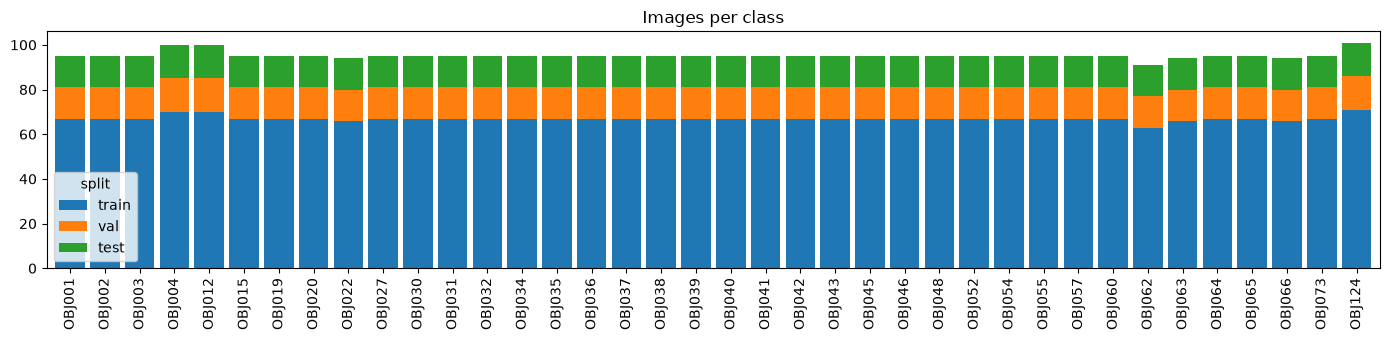

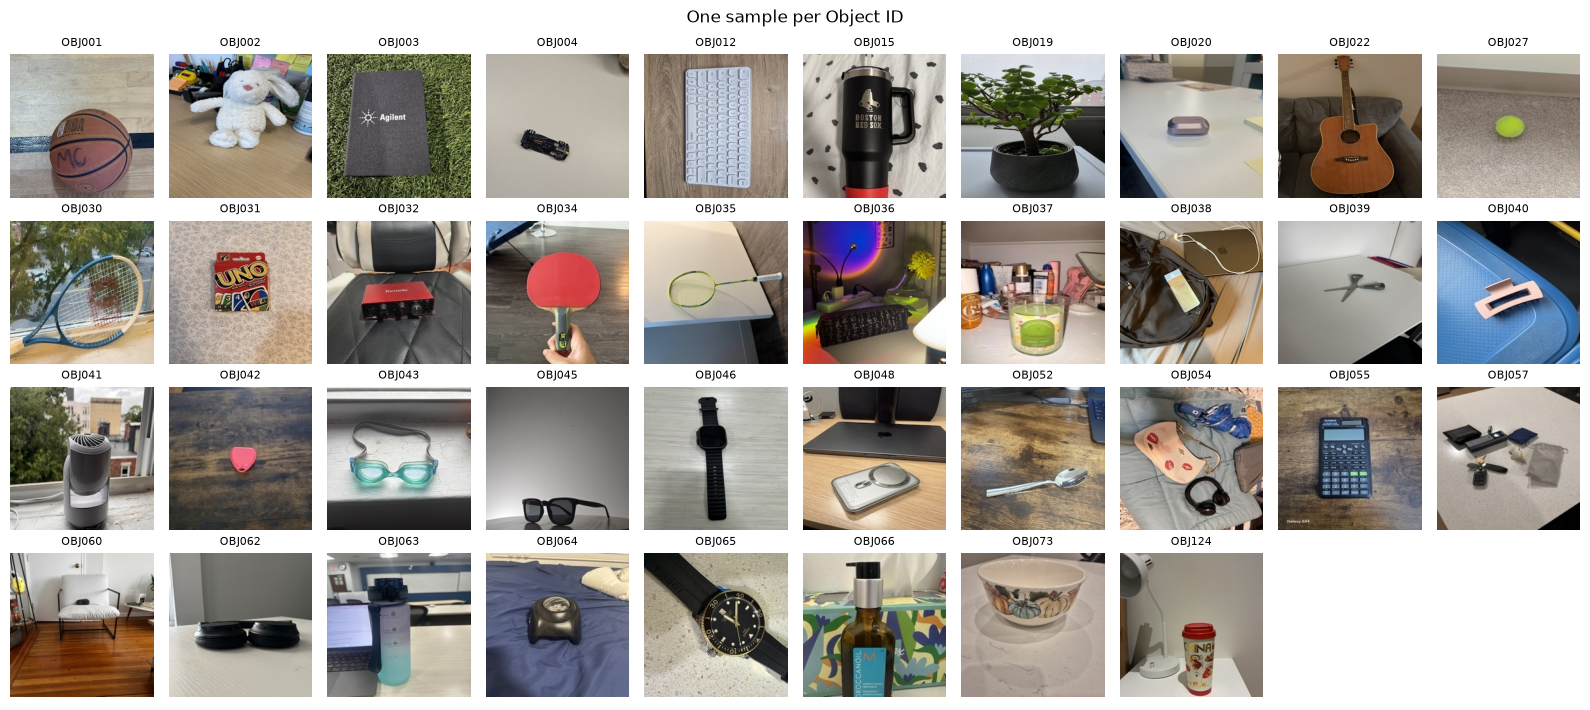

In [6]:
per_class = df.groupby(["label", "split"]).size().unstack(fill_value=0)[["train", "val", "test"]]
ax = per_class.plot.bar(stacked=True, figsize=(14, 3.5), width=0.85)
ax.set_title("Images per class"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

classes = sorted(df.label.unique())
cols = 10
fig, axes = plt.subplots(int(np.ceil(len(classes) / cols)), cols, figsize=(cols * 1.6, np.ceil(len(classes) / cols) * 1.8))
for ax, c in zip(axes.flat, classes):
    ax.imshow(Image.open(df[df.label == c].path.iloc[0])); ax.set_title(c, fontsize=8)
for ax in axes.flat:
    ax.axis("off")
plt.suptitle("One sample per Object ID"); plt.tight_layout(); plt.show()

In [7]:
def is_valid(path):
    with Image.open(path) as im:
        return im.size == (IMG_SIZE, IMG_SIZE) and im.mode == "RGB"

bad = [p for p in df.path if not is_valid(p)]
assert not bad, f"{len(bad)} invalid images: {bad[:5]}"
print(f"all images {IMG_SIZE}x{IMG_SIZE} RGB")

all images 224x224 RGB
